## **2. Build a model using transfer learning with a pretrained VGG network as the base. Add custom layers on top, including dense layers that incorporate additional features (e.g., business or photo metadata), and fine-tune the entire model.**

Importing necessary libraries

In [2]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Data loading 

In [3]:
TRAIN_DIR = r"C:\Users\User\Downloads\processed\train"
TEST_DIR = r"C:\Users\User\Downloads\processed\test"
META_PATH = r"C:\Users\User\Downloads\photos.json"
IMG_SIZE = (224, 224)
BALANCE_SIZE = 1000

In [5]:
with open(META_PATH, "r") as f:
    meta_raw = [json.loads(line) for line in f if line.strip()]

# Convert to DataFrame
meta_df = pd.json_normalize(meta_raw)
meta_df["filename"] = meta_df["photo_id"].astype(str) + ".jpg"
meta_df["caption_length"] = meta_df["caption"].fillna("").apply(len)
meta_df["business_id"] = meta_df["business_id"].astype(str)

meta_df.head()

,photo_id,business_id,caption,label,filename,caption_length
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside,zsvj7vloL4L5jhYyPIuVwg.jpg,51
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside,HCUdRJHHm_e0OCTlZetGLg.jpg,0
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink,vkr8T0scuJmGVvN2HJelEA.jpg,14
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food,pve7D6NUrafHW3EAORubyw.jpg,13
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food,H52Er-uBg6rNrHcReWTD2w.jpg,0


Label encoding 

In [6]:
# Encode and scale metadata
biz_encoder = LabelEncoder()
meta_df["business_encoded"] = biz_encoder.fit_transform(meta_df["business_id"])
scaler = StandardScaler()
meta_df[["business_encoded", "caption_length"]] = scaler.fit_transform(meta_df[["business_encoded", "caption_length"]])
meta_df.set_index("filename", inplace=True)
meta_features = ["business_encoded", "caption_length"]

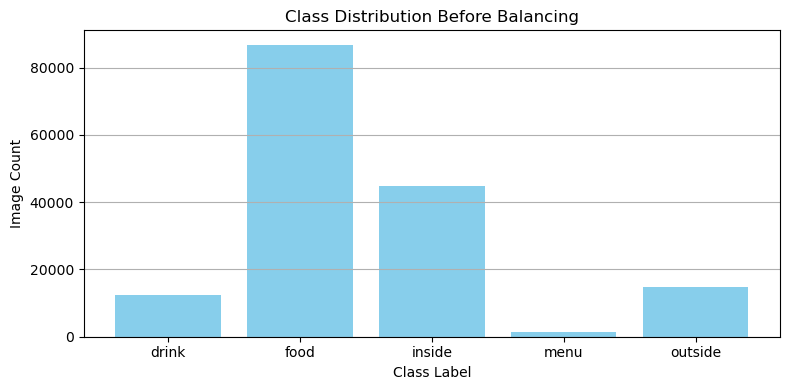

In [10]:
UNBALANCED_TRAIN_DIR = r"C:\Users\User\Downloads\processed\train"

# Count the number of images per class
class_counts = {}
for class_name in os.listdir(UNBALANCED_TRAIN_DIR):
    class_path = os.path.join(UNBALANCED_TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
        class_counts[class_name] = len(image_files)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Class Distribution Before Balancing")
plt.xlabel("Class Label")
plt.ylabel("Image Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Class distribution 

In [7]:
def load_balanced_data(data_dir):
    X_img, X_meta, y = [], [], []
    class_counts = {}
    for cls in os.listdir(data_dir):
        class_counts[cls] = 0

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path): continue
        files = os.listdir(cls_path)
        np.random.shuffle(files)
        for file in files:
            if not file.endswith('.jpg') or class_counts[cls] >= BALANCE_SIZE:
                continue
            path = os.path.join(cls_path, file)
            img = cv2.imread(path)
            if img is None: continue
            img = cv2.resize(img, IMG_SIZE)
            X_img.append(img)
            y.append(cls)
            class_counts[cls] += 1

            # metadata
            if file in meta_df.index:
                meta = meta_df.loc[file][meta_features].values.astype(np.float32)
            else:
                meta = np.zeros(len(meta_features), dtype=np.float32)
            X_meta.append(meta)
    
    return np.array(X_img)/255.0, np.array(X_meta), y, class_counts

X_img, X_meta, y, class_counts_train = load_balanced_data(TRAIN_DIR)

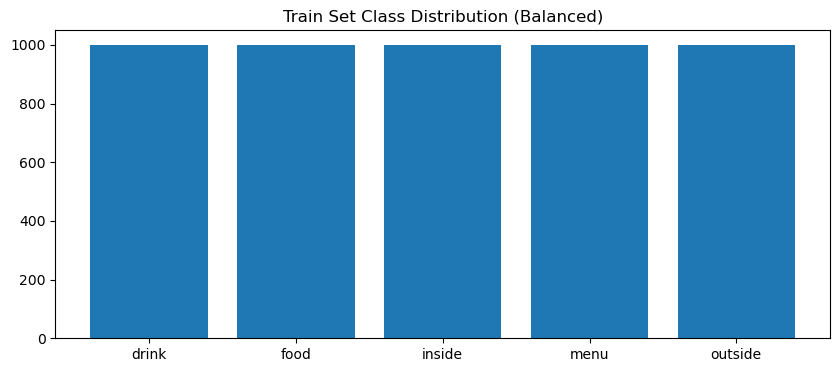

In [8]:
# Plot train class distribution
plt.figure(figsize=(10, 4))
plt.bar(class_counts_train.keys(), class_counts_train.values())
plt.title("Train Set Class Distribution (Balanced)")
plt.show()

In [11]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

In [12]:
X_img_train, X_img_val, X_meta_train, X_meta_val, y_train, y_val = train_test_split(
    X_img, X_meta, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

Model Building 

In [13]:
vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
vgg_base.trainable = False

img_input = Input(shape=(224, 224, 3))
x = vgg_base(img_input)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

meta_input = Input(shape=(X_meta.shape[1],))
m = Dense(64, activation='relu')(meta_input)
m = Dropout(0.3)(m)

combined = Concatenate()([x, m])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.3)(z)
output = Dense(len(label_encoder.classes_), activation='softmax')(z)

model = Model(inputs=[img_input, meta_input], outputs=output)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 7, 7, 512)         │      14,714,688 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 25088)             │               0 │ vgg16[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │       6,422,784 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │             192 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 320)               │               0 │ dropout[0][0],             │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 128)               │          41,088 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 128)               │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 5)                 │             645 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 34,108,817 (130.11 MB)

 Trainable params: 6,464,709 (24.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 12,929,420 (49.32 MB)

Model Training 

In [14]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
    ModelCheckpoint("vgg_metadata_model.h5", save_best_only=True)
]

history = model.fit(
    [X_img_train, X_meta_train], y_train,
    validation_data=([X_img_val, X_meta_val], y_val),
    epochs=3,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4003 - loss: 1.4176

125/125 ━━━━━━━━━━━━━━━━━━━━ 563s 4s/step - accuracy: 0.4011 - loss: 1.4161 - val_accuracy: 0.7030 - val_loss: 0.8271
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6564 - loss: 0.8994

125/125 ━━━━━━━━━━━━━━━━━━━━ 567s 5s/step - accuracy: 0.6565 - loss: 0.8993 - val_accuracy: 0.7400 - val_loss: 0.6787
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7070 - loss: 0.7749

125/125 ━━━━━━━━━━━━━━━━━━━━ 573s 5s/step - accuracy: 0.7070 - loss: 0.7748 - val_accuracy: 0.7540 - val_loss: 0.6517


In [17]:
loss, accuracy = model.evaluate([X_img_test, X_meta_test], y_test_cat, verbose=1)
print(f"\nTest Accuracy: {accuracy:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 478s 4s/step - accuracy: 0.6904 - loss: 0.8474

Test Accuracy: 0.7177


Confusion Matrix 

136/136 ━━━━━━━━━━━━━━━━━━━━ 475s 3s/step


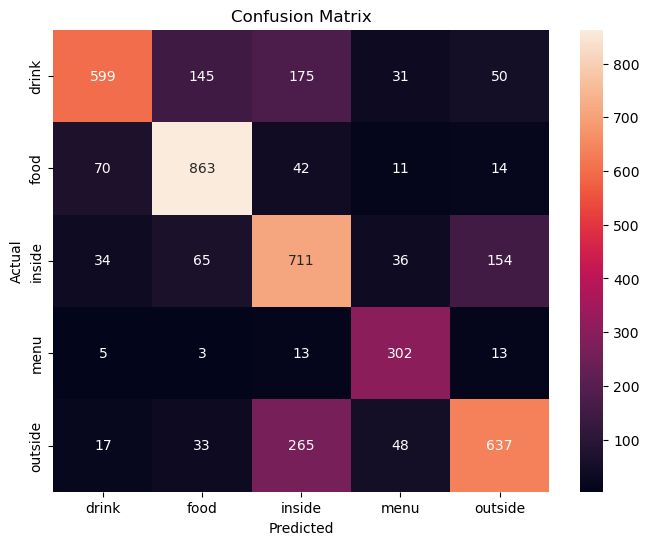

In [18]:
y_pred = model.predict([X_img_test, X_meta_test])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

       drink       0.83      0.60      0.69      1000
        food       0.78      0.86      0.82      1000
      inside       0.59      0.71      0.64      1000
        menu       0.71      0.90      0.79       336
     outside       0.73      0.64      0.68      1000

    accuracy                           0.72      4336
   macro avg       0.73      0.74      0.73      4336
weighted avg       0.73      0.72      0.72      4336



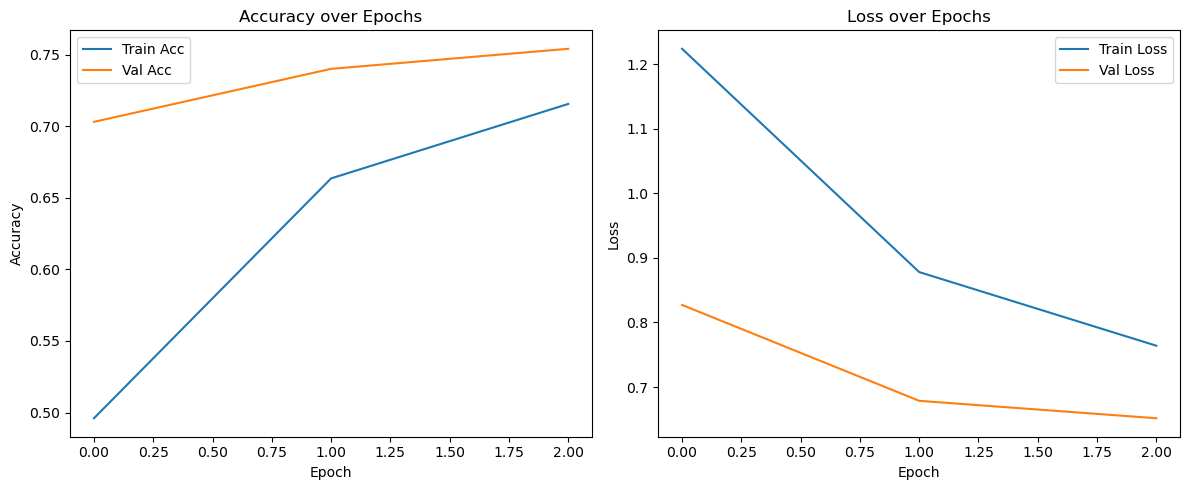

In [20]:
#Train vs Validation Accuracy & Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


ROC Curve

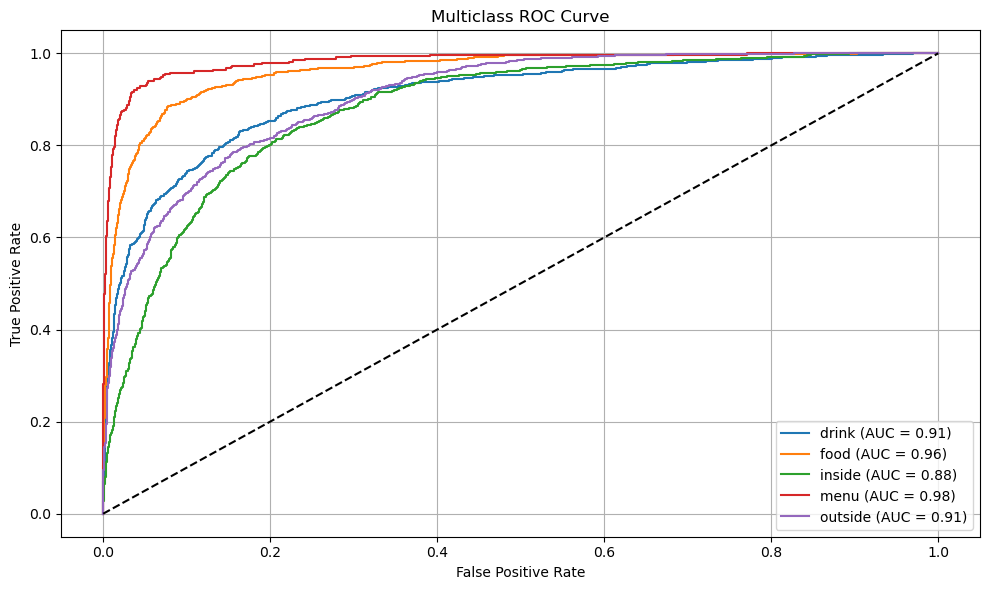

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels for each class (One-vs-Rest)
y_test_binarized = label_binarize(y_true_classes, classes=list(range(len(label_encoder.classes_))))

plt.figure(figsize=(10, 6))

# Compute ROC curve and AUC for each class
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

Model Saving 

In [22]:
model.save(r"C:\Users\User\Downloads\vgg_metadata_final_model.h5")

LLM Prompts:
- How to add dense layers on top of VGG16 and concatenate with two metadata features
- How to unfreeze the last 2 convolutional layers of VGG16 and fine-tune
- How to compare Round 1 vs Round 2 model performance.